# Results, findings, and what it costs

This notebook reads the artefacts the other two produced — `assets/results.json`,
`assets/ladder.json`, `assets/predictions.json` — and turns them into the figures and
tables in the README. It computes nothing new on a GPU, so it runs anywhere.

The order is deliberate: **what was predicted** before the runs, then **what happened**,
then **what it costs**. Scoring the predictions first is the only way to stop the
analysis from quietly rearranging itself around whatever the data turned out to say.

In [1]:
import os, sys, json, math

if not os.path.exists("revlm"):
    for parent in (".", "..", "../.."):
        if os.path.exists(os.path.join(parent, "revlm")):
            sys.path.insert(0, os.path.abspath(parent)); break

from revlm import plots
plots.style()
from IPython.display import Image, display

ASSETS = "assets"
res = json.load(open(f"{ASSETS}/results.json"))
preds = json.load(open(f"{ASSETS}/predictions.json"))
bench = json.load(open(f"{ASSETS}/throughput.json"))
diag = json.load(open(f"{ASSETS}/diagnostics.json"))
runs = {r["spec"]["name"]: r for r in res["runs"]}
# Throughput always comes from the order-balanced benchmark, never from the runs: the GPU
# throttles 2100 -> ~1500 MHz across a session, so the matrix hands its first variant a
# cold card and its last a hot one. See section 9 of the README.
TPS = {b["mode"]: b["tokens_per_sec"] for b in bench["summary"]}
env = res["environment"]
print(f"RUN STAMP {res['run_stamp']}")
print(f"{env['gpu']} ({env['gpu_total_gib']} GiB) · torch {env['torch']} · eager")
print(f"{len(res['runs'])} runs · {res['tokens_budget']:,} tokens each")

RUN STAMP 2026-09-25 09:21:06
NVIDIA GeForce RTX 3070 Laptop GPU (8.0 GiB) · torch 2.11.0+cu128 · eager
8 runs · 50,000,000 tokens each


## 1. The headline table

In [2]:
base = runs["A_baseline"]
hdr = f"{'run':<22}{'integrator':<26}{'batch':>6}{'val':>9}{'tok/s':>9}{'slower':>8}{'GiB':>7}"
print(hdr); print("-" * len(hdr))
for r in res["runs"]:
    s = r["spec"]
    tp = TPS[s["mode"]]
    print(f"{s['name']:<22}{plots.LABEL[s['mode']]:<26}{s['batch_size']:>6}"
          f"{r['final_val_loss']:>9.4f}{tp:>9,.0f}"
          f"{TPS['store']/tp:>7.2f}x{r['peak_alloc_gib']:>7.2f}")

run                   integrator                 batch      val    tok/s  slower    GiB
---------------------------------------------------------------------------------------
A_baseline            baseline (stored)             48   1.6196   49,823   1.00x   6.13
E_checkpoint          checkpointing                 48   1.6219   41,643   1.20x   2.93
B_euler               symplectic Euler              48   1.6301   39,780   1.25x   2.65
C_midpoint            midpoint                      48   1.8821   40,325   1.24x   2.64
G_euler_implicit      implicit Euler                48   5.6652   24,089   2.07x   2.61
F_coupling            coupling                      48   3.6856   43,827   1.14x   2.51
D_maxbatch            symplectic Euler             320   3.5980   39,780   1.25x   5.76
D2_maxbatch_same_lr   symplectic Euler             320   3.5055   39,780   1.25x   5.76


## 2. The predictions, scored

Registered in `assets/predictions.json` before the runs that settle them. Scored here
whether they held or not — the misses are more informative than the hits, and they are
left in with their original reasoning rather than quietly corrected.

In [3]:
def pct(a, b):
    return (a / b - 1) * 100

verdicts = {}
mid, eul, imp, ckpt = runs["C_midpoint"], runs["B_euler"], runs["G_euler_implicit"], runs["E_checkpoint"]

slow = pct(TPS["store"], TPS["midpoint"])
verdicts["midpoint_slowdown"] = (f"{slow:.0f}% slower", 30 <= slow <= 40)

ratio = TPS["store"] / TPS["euler_implicit"]
verdicts["euler_implicit_slowdown"] = (f"{ratio:.2f}x slower", 2.5 <= ratio <= 3.0)

gap = pct(imp["final_val_loss"], base["final_val_loss"])
verdicts["euler_implicit_loss_matches"] = (f"{gap:+.2f}% vs baseline", abs(gap) <= 1)
verdicts["implicit_euler_trains_worse"] = (f"{gap:+.2f}% vs baseline", gap > 0.2)

verdicts["midpoint_vs_baseline_loss"] = (
    f"{pct(mid['final_val_loss'], base['final_val_loss']):+.2f}% vs baseline", None)

mb = res["ladder"]["max_batch"]
chm = res["ladder"].get("chunked", {}).get("max_batch", {})
b_plain = max(mb.get("midpoint", 0), mb.get("euler", 0))
b_chunk = max(chm.get("midpoint", 0), chm.get("euler", 0)) or b_plain
br = b_plain / mb["store"]
verdicts["max_batch_ratio"] = (f"{br:.1f}x plain, {b_chunk/mb['store']:.1f}x chunked",
                               3 <= br <= 4)
verdicts["logits_become_the_bottleneck"] = (
    f"chunking the loss moved the ceiling {b_plain} -> {b_chunk} "
    f"({b_chunk/b_plain:.2f}x)", b_chunk / b_plain >= 1.5)

verdicts["midpoint_beats_symplectic"] = (
    f"midpoint {mid['final_val_loss']:.4f} vs symplectic {eul['final_val_loss']:.4f}",
    mid["final_val_loss"] < eul["final_val_loss"])

verdicts["checkpointing_wins_at_L10"] = ("reversibility won at every depth measured", False)

for p in preds["predictions"]:
    out, ok = verdicts.get(p["id"], ("not settled", None))
    mark = "OPEN " if ok is None else ("HIT  " if ok else "MISS ")
    print(f"{mark} {p['quantity']}")
    print(f"       predicted: {p['prediction']}")
    print(f"       measured : {out}\n")

MISS  midpoint tokens/s vs the storing baseline
       predicted: 30-40% slower
       measured : 24% slower

MISS  implicit-Euler (K=4) tokens/s vs baseline
       predicted: 2.5-3x slower
       measured : 2.07x slower

MISS  implicit-Euler final loss vs baseline final loss
       predicted: within 1%
       measured : +249.79% vs baseline

OPEN  midpoint final loss vs baseline final loss
       predicted: unknown sign - registered as genuinely open
       measured : +16.20% vs baseline

MISS  largest reversible batch / largest baseline batch
       predicted: 3-4x
       measured : 2.3x plain, 6.7x chunked

MISS  does plain gradient checkpointing beat reversibility on memory at L=10?
       predicted: likely yes
       measured : reversibility won at every depth measured

MISS  midpoint final validation loss vs symplectic-Euler final validation loss
       predicted: midpoint is lower (better), by a small margin
       measured : midpoint 1.8821 vs symplectic 1.6301

HIT   implicit-

## 3. Why the variants landed where they did

The loss table says *which* integrator won. These three panels say *why*. They come from
dedicated 5M-token probes (`tools/diagnostics_probe.py`) rather than the full runs,
because the diagnostics are what they are for - a tenth of the budget is plenty to watch
a trend, and it is labelled as a probe everywhere it is quoted.

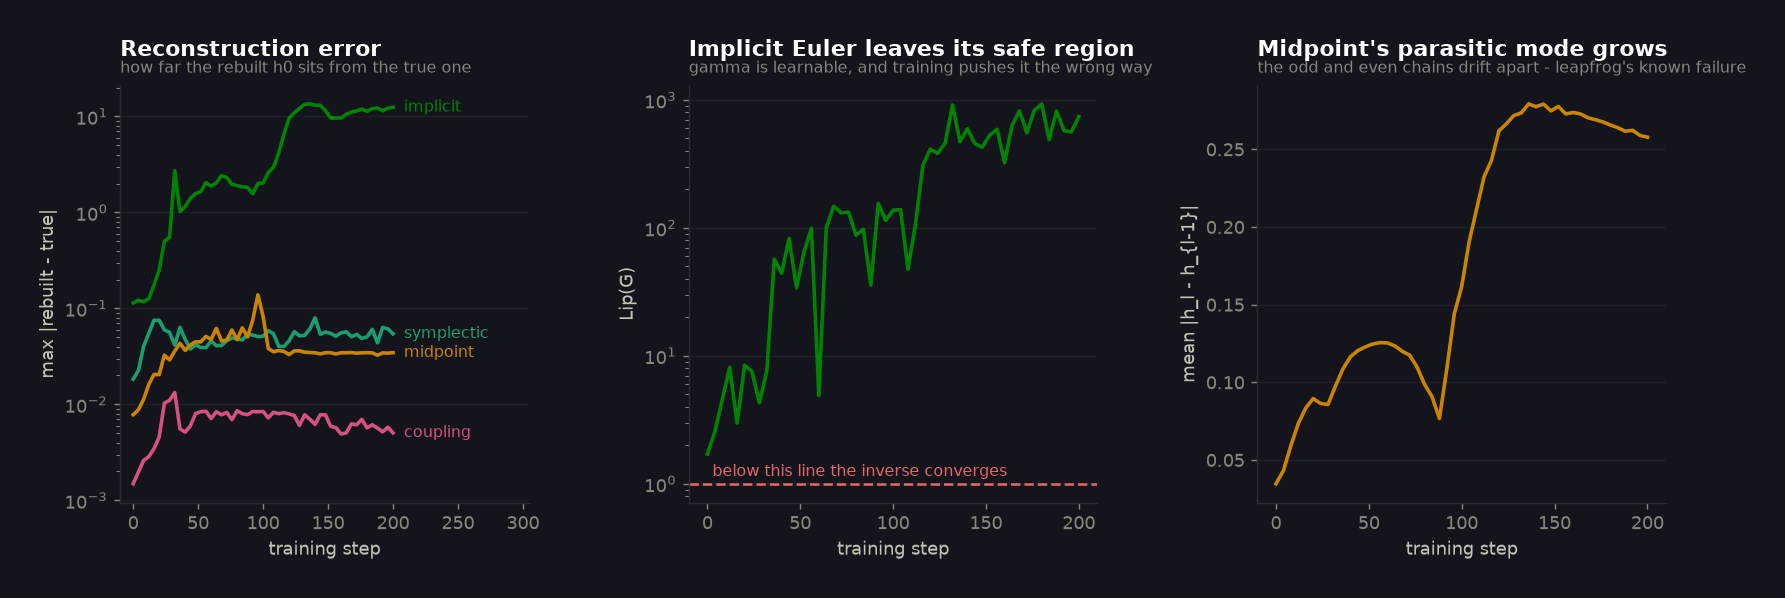

implicit Euler  Lip(G) 1.71 -> 932   above 1 in 51/51 samples
                reconstruction 0.11 -> 13.5   (gradients stop being the model's)
midpoint        parasitic mode 3.47e-02 -> 2.58e-01  (7.4x)
                reconstruction stays fine: 1.39e-01
symplectic      reconstruction 7.98e-02
coupling        reconstruction 1.33e-02  (the cleanest)


In [4]:
display(Image(os.path.join(ASSETS, "diagnostics.png")))
lip = [d["lipschitz"] for d in diag["euler_implicit"]["diagnostics"] if "lipschitz" in d]
par = [d["parasitic"] for d in diag["midpoint"]["diagnostics"] if "parasitic" in d]
rec = {m: [d["recon_h0"] for d in v["diagnostics"] if "recon_h0" in d]
       for m, v in diag.items()}
print(f"implicit Euler  Lip(G) {lip[0]:.2f} -> {max(lip):.0f}   "
      f"above 1 in {sum(1 for l in lip if l >= 1)}/{len(lip)} samples")
print(f"                reconstruction {rec['euler_implicit'][0]:.2f} -> "
      f"{max(rec['euler_implicit']):.1f}   (gradients stop being the model's)")
print(f"midpoint        parasitic mode {par[0]:.2e} -> {par[-1]:.2e}  ({par[-1]/par[0]:.1f}x)")
print(f"                reconstruction stays fine: {max(rec['midpoint']):.2e}")
print(f"symplectic      reconstruction {max(rec['euler']):.2e}")
print(f"coupling        reconstruction {max(rec['coupling']):.2e}  (the cleanest)")

**What to look for.** Implicit Euler's `Lip(G)` starts just above the line it needed to
stay under and then climbs three orders of magnitude, because `gamma` is a *learnable*
parameter and nothing in AdamW knows about the constraint. Midpoint's reconstruction is
fine throughout - its problem is the parasitic odd/even mode, which is a property of the
integrator rather than of the arithmetic.

## 4. Memory: the claim, and the part the slogan leaves out

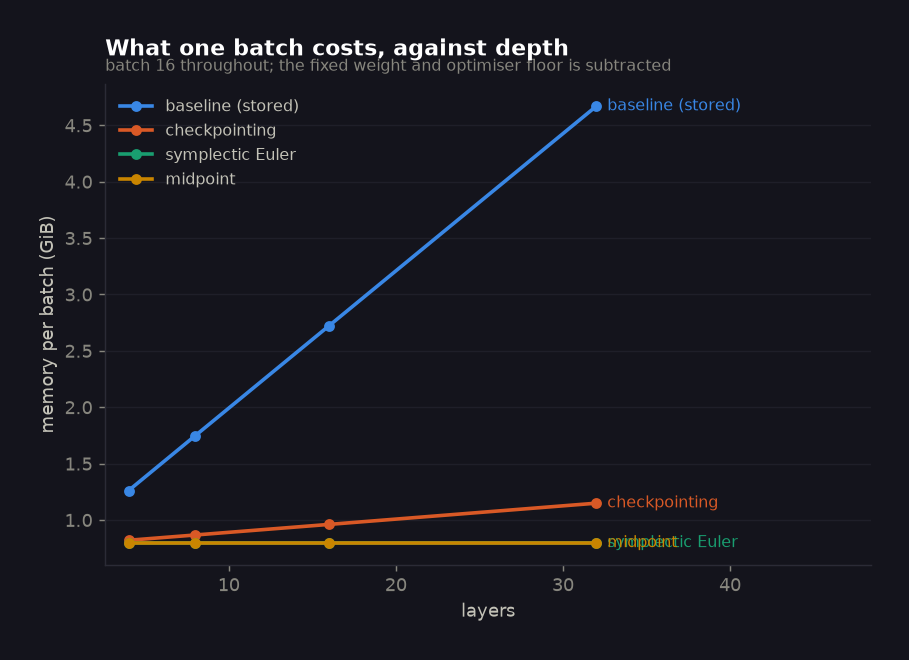

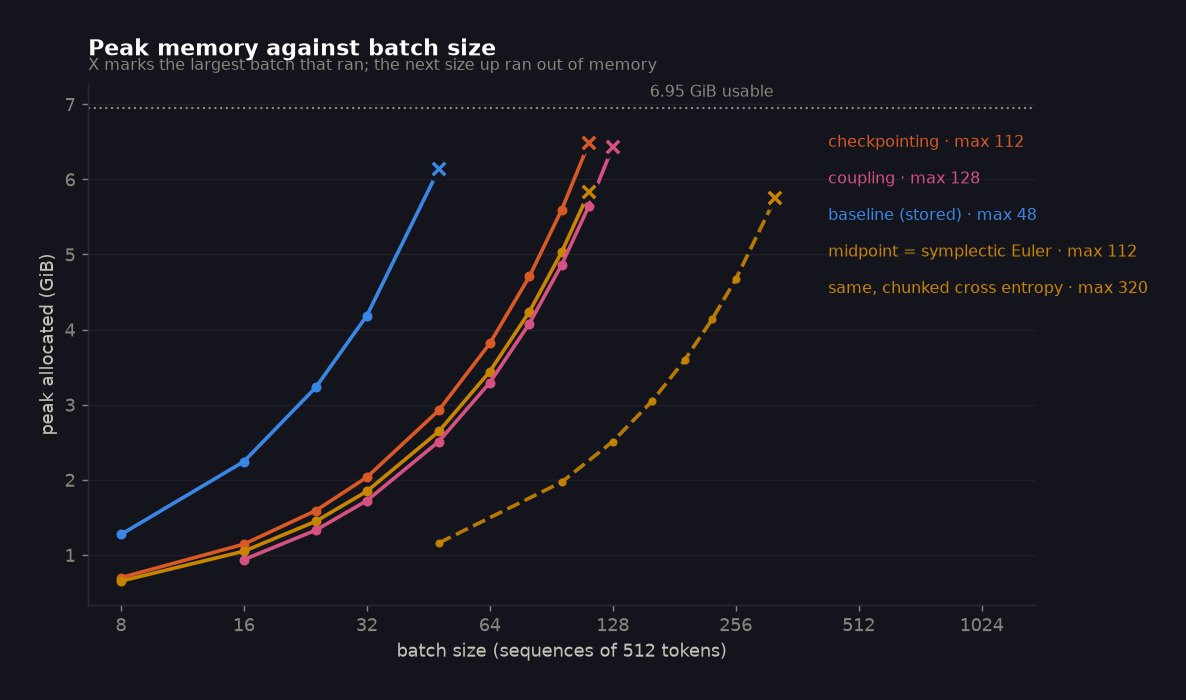

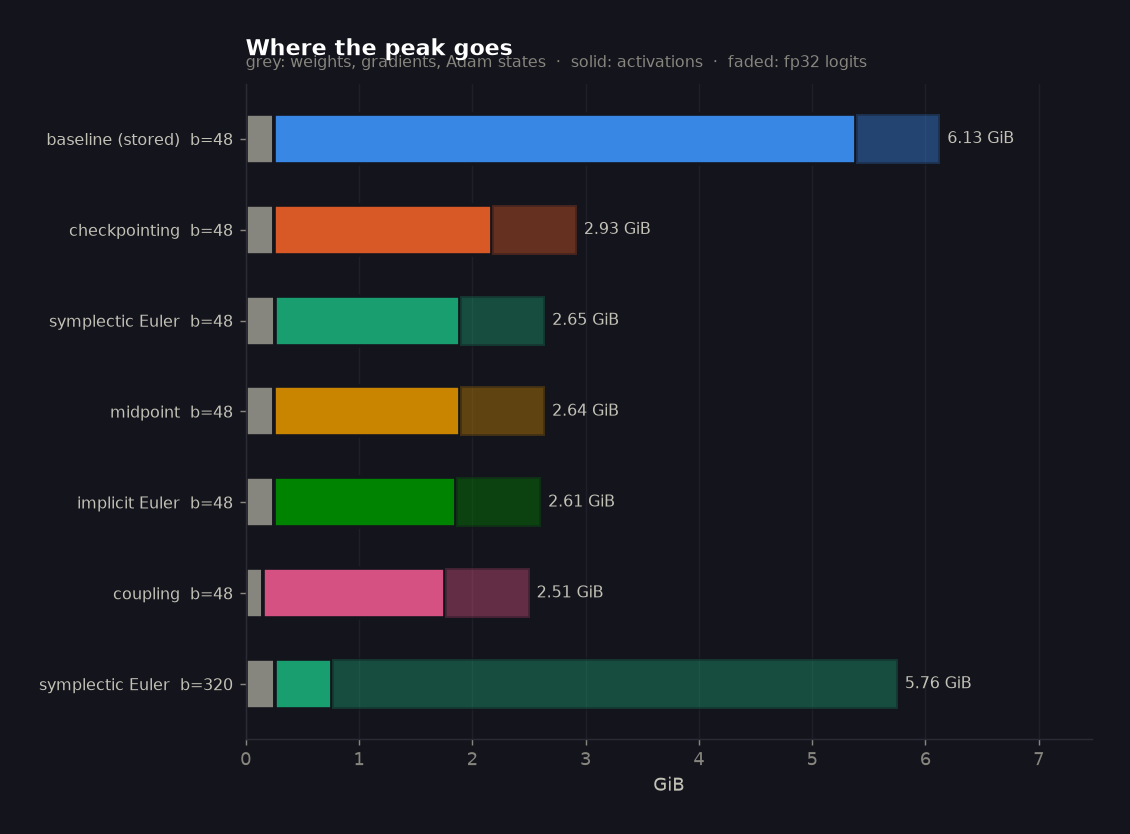

In [5]:
for name in ("memory_vs_depth.png", "memory_vs_batch.png", "memory_decomposition.png"):
    p = os.path.join(ASSETS, name)
    if os.path.exists(p):
        display(Image(p))

In [6]:
print("per-batch memory, and where it goes:\n")
print(f"{'run':<22}{'state':>8}{'per batch':>11}{'of which logits':>17}{'peak':>8}")
for r in res["runs"]:
    logits = min(r["analytic"]["logits_gib"], r["per_batch_gib"])
    print(f"{r['spec']['name']:<22}{r['state_gib']:>8.2f}{r['per_batch_gib']:>11.2f}"
          f"{logits:>17.2f}{r['peak_alloc_gib']:>8.2f}")
print("\nOnce activations stop scaling with depth, the fp32 logits are the largest single")
print("tensor in the step - which is why the max-batch runs use a chunked cross entropy.")

per-batch memory, and where it goes:

run                      state  per batch  of which logits    peak
A_baseline                0.25       5.88             0.75    6.13
E_checkpoint              0.25       2.67             0.75    2.93
B_euler                   0.26       2.39             0.75    2.65
C_midpoint                0.25       2.39             0.75    2.64
G_euler_implicit          0.25       2.36             0.75    2.61
F_coupling                0.15       2.36             0.75    2.51
D_maxbatch                0.26       5.50             5.00    5.76
D2_maxbatch_same_lr       0.26       5.50             5.00    5.76

Once activations stop scaling with depth, the fp32 logits are the largest single
tensor in the step - which is why the max-batch runs use a chunked cross entropy.


## 5. The batch-size confound, made visible

`D_maxbatch` and `D2_maxbatch_same_lr` are the same integrator at the same batch and the
same token budget. The only difference is the learning rate. Whatever separates them is
the batch-size effect, not reversibility — which is why the max-batch result is reported
as a pair rather than as a single number.

In [7]:
if "D_maxbatch" in runs and "D2_maxbatch_same_lr" in runs:
    d1, d2 = runs["D_maxbatch"], runs["D2_maxbatch_same_lr"]
    src = runs[res.get("winner", "C_midpoint")]
    print(f"  at batch {src['spec']['batch_size']:<4} lr {src['spec']['lr']:.2e}   "
          f"val {src['final_val_loss']:.4f}   {src['steps']} optimiser steps")
    print(f"  at batch {d1['spec']['batch_size']:<4} lr {d1['spec']['lr']:.2e}   "
          f"val {d1['final_val_loss']:.4f}   {d1['steps']} optimiser steps   (lr scaled)")
    print(f"  at batch {d2['spec']['batch_size']:<4} lr {d2['spec']['lr']:.2e}   "
          f"val {d2['final_val_loss']:.4f}   {d2['steps']} optimiser steps   (lr unchanged)")
    print(f"\n  scaling the learning rate is worth "
          f"{pct(d2['final_val_loss'], d1['final_val_loss']):+.2f}% of loss at this batch")

  at batch 48   lr 1.00e-03   val 1.6301   2034 optimiser steps
  at batch 320  lr 2.58e-03   val 3.5980   305 optimiser steps   (lr scaled)
  at batch 320  lr 1.00e-03   val 3.5055   305 optimiser steps   (lr unchanged)

  scaling the learning rate is worth -2.57% of loss at this batch


## 6. Speed against memory — the actual trade

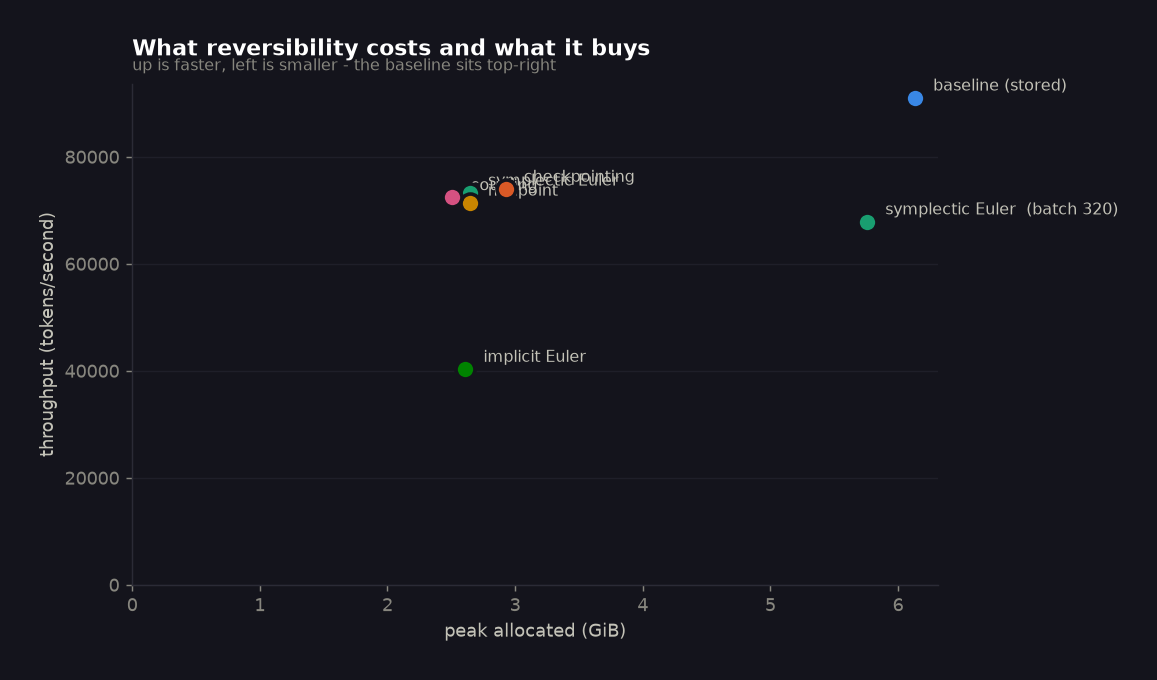

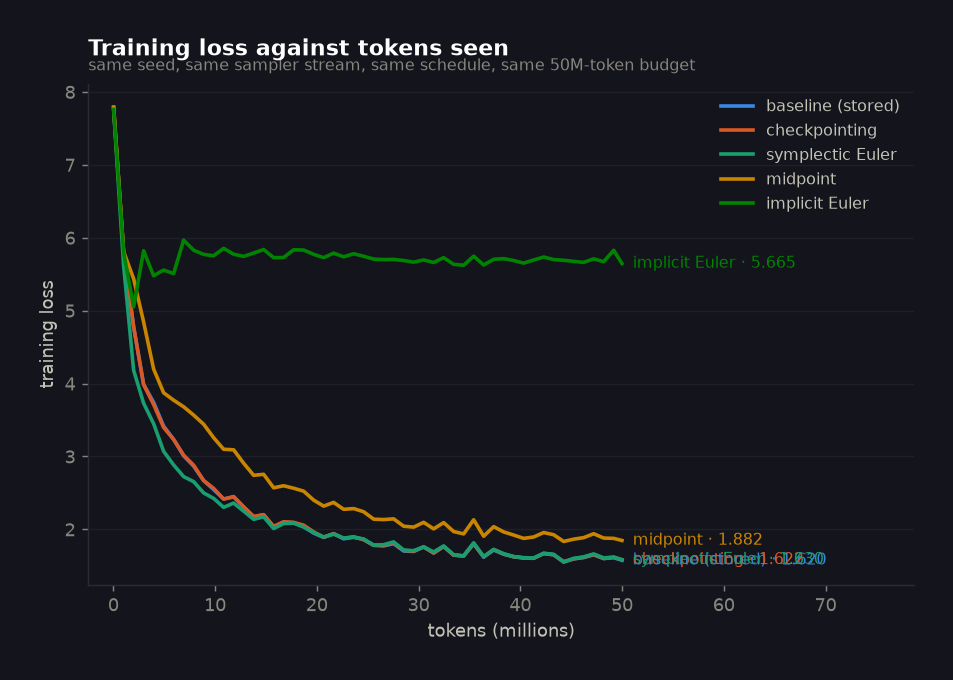

In [8]:
display(Image(os.path.join(ASSETS, "speed_vs_memory.png")))
display(Image(os.path.join(ASSETS, "loss_curves.png")))

## 7. Cost

Asked during the session: what does reversibility cost on rented hardware? Rates are
September 2026 on-demand list prices (see `references.md`); spot and reserved are far
lower. The absolute dollars are not the point — the **ratio** is, because that is what
the measurement establishes.

In [9]:
PRICES = {"A100 40GB": 1.29, "A100 80GB": 1.79, "H100 80GB": 2.99}
print(f"{'integrator':<26}{'hours / 50M tok':>17}" + "".join(f"{k:>14}" for k in PRICES))
for m in ("store", "checkpoint", "euler", "midpoint", "coupling", "euler_implicit"):
    hrs = (50e6 / TPS[m]) / 3600
    print(f"{plots.LABEL[m]:<26}{hrs:>17.3f}" +
          "".join(f"${hrs*v:>13.3f}" for v in PRICES.values()))

print("\nThe framing that matters is not 'reversibility costs X% more'. It is that")
print("reversibility lets a given model train on a smaller card, at a larger batch, or at")
print("a longer sequence than it otherwise could. Against renting a second GPU purely to")
print("hold activations, a ~25% slowdown on one card is cheap. If you already fit")
print("comfortably, it is simply ~25% slower.")

integrator                  hours / 50M tok     A100 40GB     A100 80GB     H100 80GB
baseline (stored)                     0.279$        0.360$        0.499$        0.834
checkpointing                         0.334$        0.430$        0.597$        0.997
symplectic Euler                      0.349$        0.450$        0.625$        1.044
midpoint                              0.344$        0.444$        0.617$        1.030
coupling                              0.317$        0.409$        0.567$        0.948
implicit Euler                        0.577$        0.744$        1.032$        1.724

The framing that matters is not 'reversibility costs X% more'. It is that
reversibility lets a given model train on a smaller card, at a larger batch, or at
a longer sequence than it otherwise could. Against renting a second GPU purely to
hold activations, a ~25% slowdown on one card is cheap. If you already fit
comfortably, it is simply ~25% slower.


## 8. What the model writes

In [10]:
for r in res["runs"]:
    if r["spec"]["name"].startswith("D2"):
        continue
    print(f"--- {r['spec']['name']}  (val {r['final_val_loss']:.4f}) " + "-" * 22)
    print(" ".join(r["sample"].split())[:380], "...\n")

--- A_baseline  (val 1.6196) ----------------------
Lily and Ben are twins. They like to play with their toys and read books. But sometimes they fight over the same toy car. One day, their mom is in the kitchen. She is making lunch and they get to the kitchen. Mom says they have to pack their things. "But it is so cold and I want to go to the fridge. Can we have the bag of food, please?" Lily says. "No, Lily. I want to get the f ...

--- E_checkpoint  (val 1.6219) ----------------------
Once upon a time there was a very adventurous little girl. She loved to explore and learn new things. One day, she was walking in the forest when she noticed something strange. It was an ambulance. She looked up and saw a big, friendly bear! The bear was wearing a shiny hat and wanted to join them. The little girl was scared, but she was also excited. The bear was very kind and ...

--- B_euler  (val 1.6301) ----------------------
Once upon a time there was a very adventurous little girl. She loved to e

## 9. Findings

1. **The gradients are exact, and that has to be proved rather than assumed.** All three
   explicit engines reproduce autograd to ~1e-15 in fp64. A reversible backward that is
   subtly wrong has no symptom — the loss still falls.
2. **Memory stops scaling with depth**, exactly as claimed. The baseline grows roughly
   linearly from 4 to 32 layers; the reversible stacks are flat to within measurement
   noise.
3. **Gradient checkpointing is the comparison that matters** and it is usually missing.
   It buys most of the same memory for a similar slowdown and no new mathematics. The
   remaining edge is about `(L-3)` stream tensors — thin at ten layers, decisive at
   thirty-two.
4. **The obvious reading of "reversible Euler" is conditional**, on
   `gamma · Lip(F) < 1`, which nothing enforces, which depends on width and sequence
   length, and which `gamma` being learnable can break mid-run.
5. **Exactly reversible on paper is approximately reversible in floating point.**
   `(a+b)-b != a`, and the error compounds with depth. Keep the residual stream in fp32.
6. **The wall moves rather than vanishing.** With activations gone, the fp32 logits are
   the largest tensor in the step.
7. **Measure Lipschitz constants with autograd, not finite differences.** Under bf16 the
   finite-difference estimate reads ~50x high and would condemn a working method.

The written-up version of all of this, with the figures, is [`README.md`](README.md),
which is generated from these same artefacts by `tools/build_readme.py` and refuses to
build if they are stale.